In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
CUDA_LAUNCH_BLOCKING=1

def single_S(y,x_left,x_right,y_below,y_upper,center,r): # Single source
    cond=(y[:,0]-center[0])**2+(y[:,1]-center[1])**2<=r**2
    return 0.5*np.exp(-550*((y[:,0]-center[0])**2+(y[:,1]-center[1])**2))*cond

def ana_S(y,x_left,x_right,y_below,y_upper,center,r): # Total source
    cond1=(y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2<=r**2
    cond2=(y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2<=r**2
    return 0.5*np.exp(-550*((y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2))*cond1+0.5*np.exp(-550*((y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2))*cond2



cuda:1


In [2]:
import pickle

with open("./Noise/noise=10%/cells_store_33.pkl", "rb") as f:
    cells_store=pickle.load(f)
x = np.linspace(-0.3, 0.3, 301)
y = np.linspace(-0.3, 0.3, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
S_num_10=np.load("./Noise/noise=10%/S_num_0.0001.npy")
# Create data
S_num_store=np.load("./Noise/noise=10%/S_num_store.npy")

In [3]:
g_S=np.load("./Noise/noise=10%/g_S.npy")

DBSCAN eps = 0.010000 (5.000000 * h, h = 0.002000)
Number of detected clusters: 2
  CV of S_num: 0.744
Cluster 0: AR=1.03
  Res_Rect=0.078904 vs Res_Ellip=0.037945
  center=(-0.0606, 0.0001)
  -> Decision: Ellipsoid (Exp)
  CV of S_num: 0.744
Cluster 1: AR=1.03
  Res_Rect=0.080103 vs Res_Ellip=0.036352
  center=(0.0804, 0.0000)
  -> Decision: Ellipsoid (Exp)


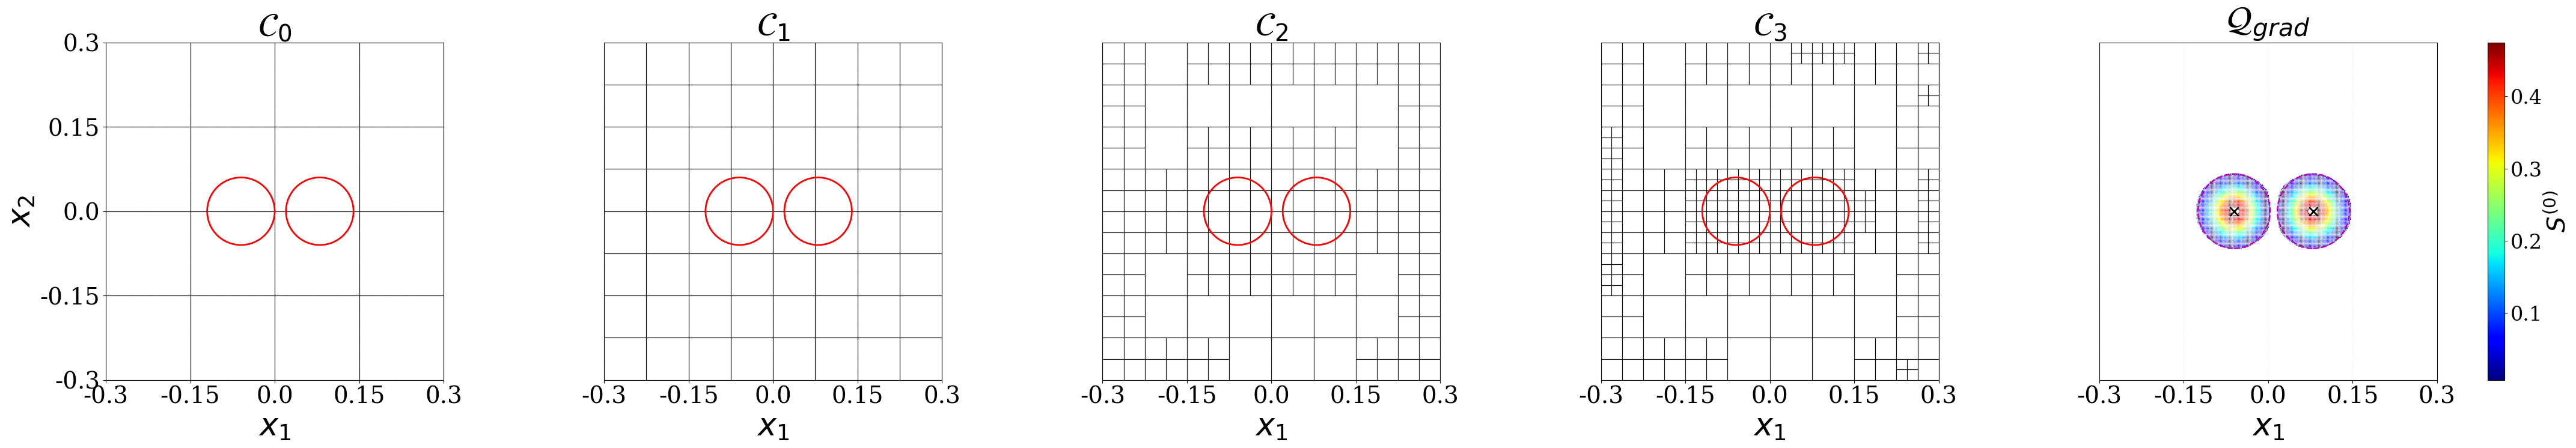

In [4]:
import visual
import bound_detect
reload(bound_detect)
reload(visual)
v=visual.GridMeshVisualizer()
fig=v.plot_mesh_evolution(cells_store, S_num_stores=S_num_store[-1], points=samples, save_path=None,label=True,g_S=g_S,temp=True)

In [5]:
fig.savefig("./Noise/noise=10%/mesh_evo_detect1.pdf", dpi=300, bbox_inches='tight')

Plot saved as ./Noise/noise=10%/S_true.pdf


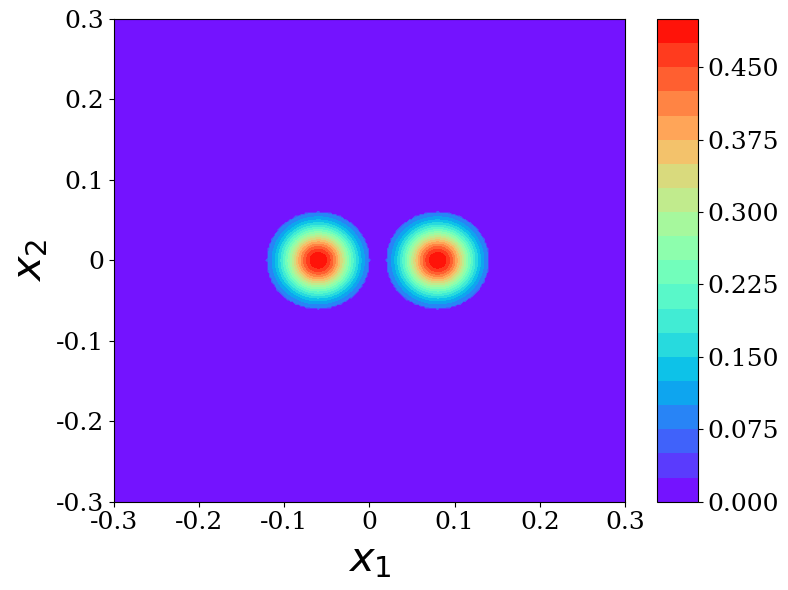

Plot saved as ./Noise/noise=10%/S_num_10.pdf


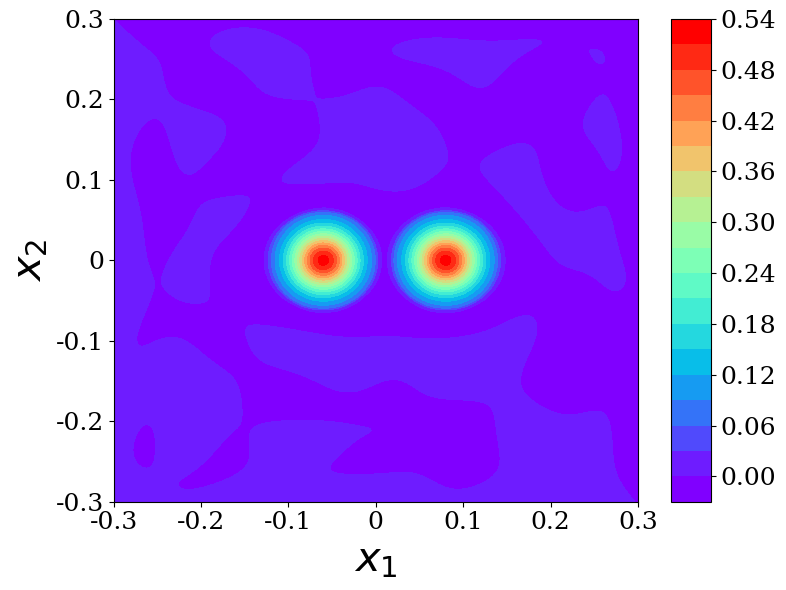

Plot saved as ./Noise/noise=10%/abs_S.pdf


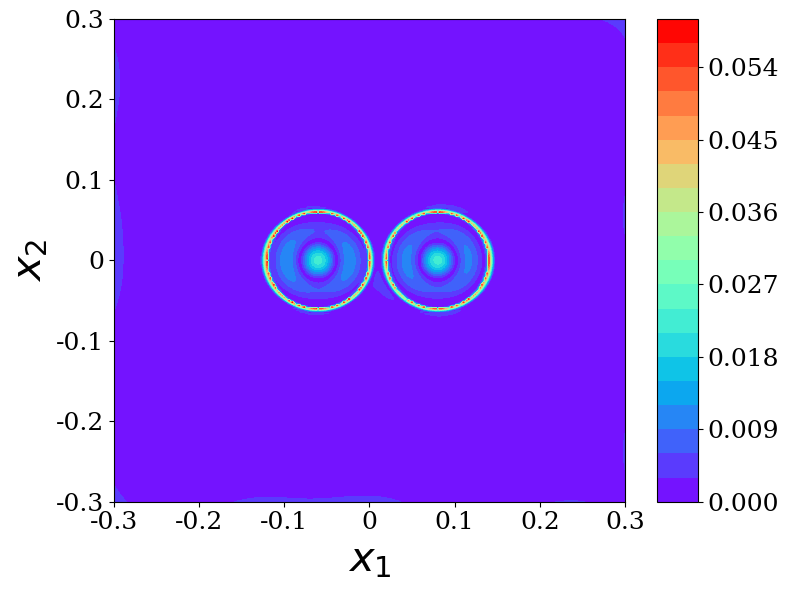

In [6]:
import visual
S_num_10=np.load("./Noise/noise=10%/S_num_0.0001.npy")
# Create data
x = np.linspace(-0.3, 0.3, 301)
y = np.linspace(-0.3, 0.3, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
center=np.array([[-0.06,0],[0.08,0]])
r=0.06
S_true=ana_S(samples,[],[],[],[],center,r).reshape(len(x),len(y))
output_dictionary="./Noise/noise=10%"
visual.draw(X,Y,S_true,output_dictionary,"S_true.pdf")
visual.draw(X,Y,S_num_10,output_dictionary,"S_num_10.pdf")
visual.draw(X,Y,np.abs(S_true-S_num_10),output_dictionary,"abs_S.pdf")